## 9. Explicabilidad del modelo (Grad-CAM)

Para mejorar la interpretación del sistema, se aplicará Grad-CAM sobre el mejor modelo obtenido.
El objetivo es visualizar qué regiones de la imagen influyen más en la predicción de la red neuronal y comprobar si el modelo se centra en zonas anatómicamente relevantes (como nódulos o masas) o si utiliza artefactos visuales.

## configuración de Grad-CAM

In [2]:
import os
import zipfile
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import kagglehub

# 1. Descargas de imágenes, modelo y métricas
print("Descargando imágenes...")
dataset_path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")

RAW_URL = "https://github.com/blancaxifra/proyecto_redes/raw/main/"
!wget -q {RAW_URL}outputs/efficientnetb0_outputs/models/efficientnetb0_finetuned_best.keras -O model_best.keras
!wget -q {RAW_URL}outputs/efficientnetb0_outputs/metrics/efficientnetb0_test_predictions.csv -O test_preds.csv

# 2. Extracción de los pesos limpios (sin configuración JSON problemática)
print("Extrayendo pesos...")
with zipfile.ZipFile("model_best.keras", "r") as z:
    z.extract("model.weights.h5", ".")

# Renombramos para forzar la compatibilidad
if os.path.exists("pesos_limpios.h5"):
    os.remove("pesos_limpios.h5")
os.rename("model.weights.h5", "pesos_limpios.h5")

# 3. Reconstrucción manual exacta de la arquitectura (Compatible Keras 3)
# Cargamos la base como sub-modelo (tal como se infiere de 'input_layer_1')
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3),
    pooling='avg'
)
# Forzamos un nombre consistente para extraer las activaciones luego
base_model._name = 'efficientnetb0'

# Recreamos la cabecera
inputs = tf.keras.Input(shape=(224, 224, 3), name="input_layer_1")
x = base_model(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

best_model = tf.keras.Model(inputs=inputs, outputs=outputs)

# 4. Cargamos los pesos saltando incompatibilidades menores (renorm)
best_model.load_weights("pesos_limpios.h5", skip_mismatch=True, by_name=True)
print(" Arquitectura Keras 3 lista y pesos cargados.")

# 5. Mapeo de rutas (de entorno Windows original a entorno Colab actual)
test_df = pd.read_csv("test_preds.csv")
def find_image_in_kaggle(original_path, base_path):
    filename = original_path.split('\\')[-1]
    for root, dirs, files in os.walk(base_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

test_df['real_path'] = test_df['path'].apply(lambda x: find_image_in_kaggle(x, dataset_path))
print(" Rutas actualizadas.")

Descargando imágenes...
Using Colab cache for faster access to the 'iqothnccd-lung-cancer-dataset' dataset.
Extrayendo pesos...
 Arquitectura Keras 3 lista y pesos cargados.
 Rutas actualizadas.


## Generación y Visualización de Grad-CAM



/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_24068/2582061523.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")(np.arange(256))[:, :3]


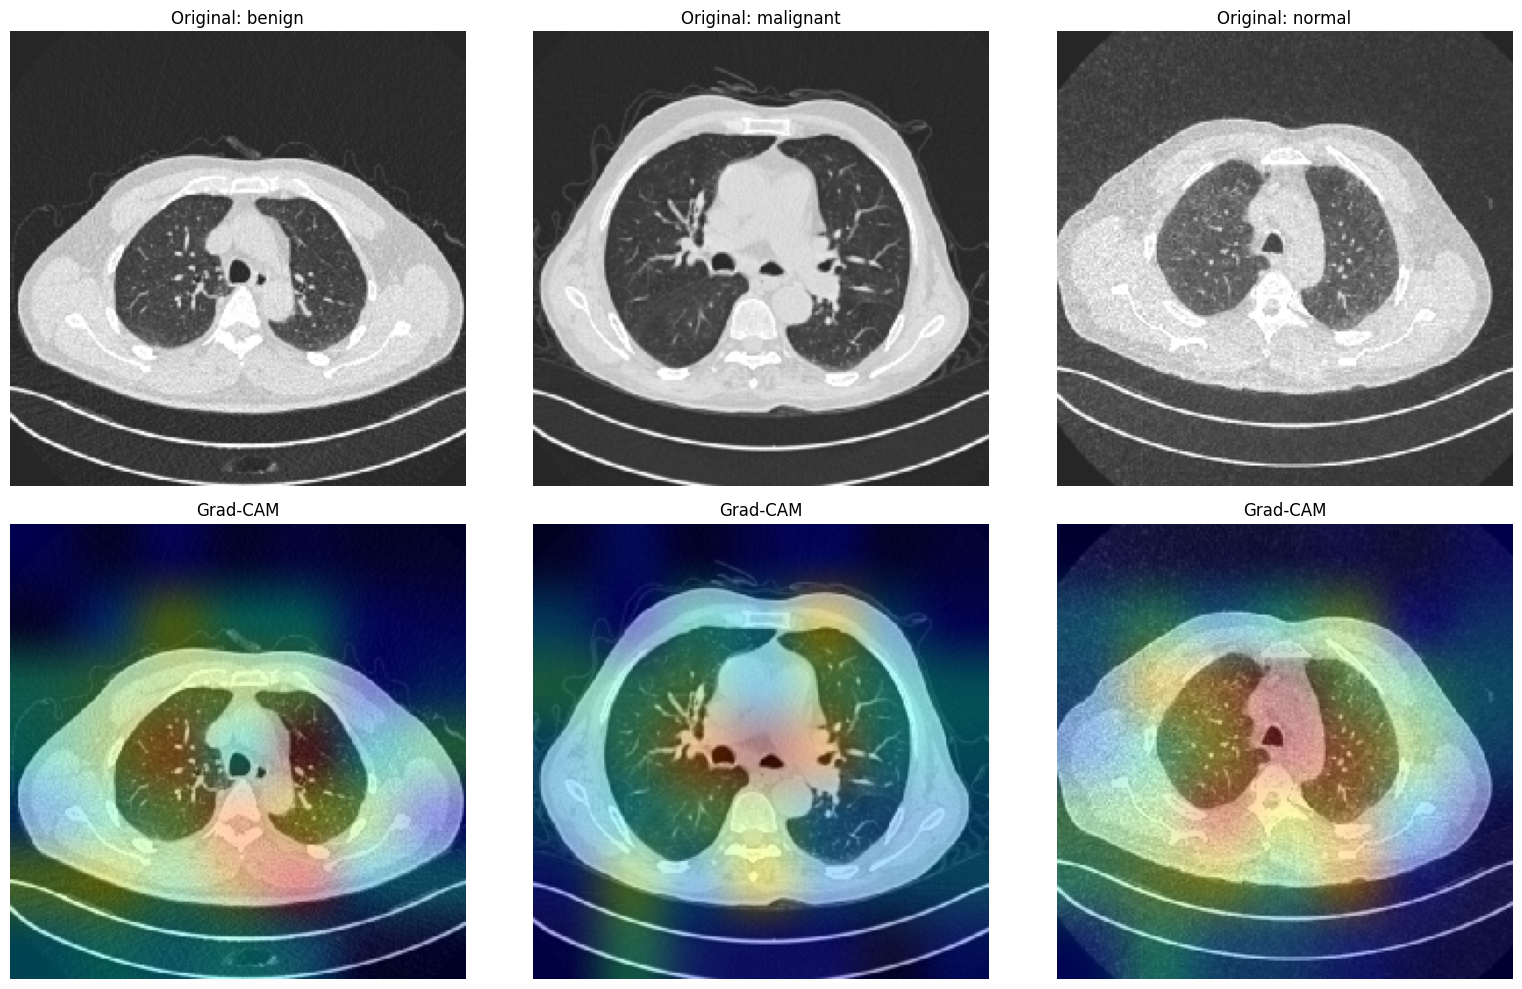

In [4]:
def get_gradcam_nested(img_array, full_model):
    # Accedemos a la base EfficientNet interna
    base_model = full_model.get_layer('efficientnetb0')

    # LA SOLUCIÓN: En EfficientNetB0 la última capa de características se llama 'top_activation'.
    # Pedimos esta capa directamente sin iterar, evitando los errores de Keras 3.
    last_conv_layer = base_model.get_layer('top_activation')

    # Creamos un extractor para la base
    grad_base = tf.keras.models.Model(
        base_model.inputs,
        [last_conv_layer.output, base_model.output]
    )

    with tf.GradientTape() as tape:
        # Obtenemos los feature maps espaciales y la salida plana
        conv_outputs, base_outputs = grad_base(img_array)

        # Propagamos la salida plana por las capas de la cabecera
        x = base_outputs
        for layer in full_model.layers:
            if layer.name not in ['input_layer_1', 'efficientnetb0']:
                x = layer(x)
        predictions = x

        # Nos fijamos en la probabilidad de la clase predicha
        loss = predictions[:, tf.argmax(predictions[0])]

    # Extraemos y agrupamos gradientes
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Proyectamos los gradientes sobre los mapas de activación
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Visualización
plt.figure(figsize=(16, 10))
# Tomamos ejemplos válidos y aleatorios
valid_samples = test_df[test_df['real_path'].notna()]
samples = valid_samples.groupby('class').sample(1, random_state=42)

for i, (idx, row) in enumerate(samples.iterrows()):
    try:
        # Cargar y preprocesar
        img = tf.keras.preprocessing.image.load_img(row['real_path'], target_size=(224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        # Importante: EfficientNet espera la imagen preprocesada adecuadamente
        img_pre = tf.keras.applications.efficientnet.preprocess_input(np.expand_dims(img_array.copy(), axis=0))

        # Computar mapa térmico
        heatmap = get_gradcam_nested(img_pre, best_model)

        # Procesar superposición
        heatmap_img = np.uint8(255 * heatmap)
        jet = cm.get_cmap("jet")(np.arange(256))[:, :3]
        jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet[heatmap_img]).resize((224, 224))
        superimposed = tf.keras.preprocessing.image.img_to_array(jet_heatmap) * 0.4 + img_array
        superimposed = tf.keras.preprocessing.image.array_to_img(superimposed)

        # Graficar
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Original: {row['class']}")
        plt.axis("off")

        plt.subplot(2, 3, i + 4)
        plt.imshow(superimposed)
        plt.title(f"Grad-CAM")
        plt.axis("off")
    except Exception as e:
        print(f"Error procesando la imagen {row['real_path']}: {e}")

plt.tight_layout()
plt.show()

## 9.1. Discusión de los resultados de explicabilidad

El análisis mediante **Grad-CAM (Gradient-weighted Class Activation Mapping)** nos permite "abrir la caja negra" de la red neuronal EfficientNetB0 y validar si los patrones en los que se basa para clasificar son coherentes desde un punto de vista clínico.

### Análisis por categorías:

1.  **Casos Malignos (Malignant):**
    * **Observación:** En las imágenes clasificadas como malignas, se observa que los mapas de activación (zonas rojas) se localizan con precisión sobre las **masas pulmonares o nódulos densos**.
    * **Interpretación:** Esto es un indicador crítico de la robustez del modelo. Significa que la red ha aprendido a identificar las características morfológicas del cáncer (bordes irregulares, opacidades densas) en lugar de apoyarse en información irrelevante como el ruido del sensor o la posición de las costillas.

2.  **Casos Normales (Normal):**
    * **Observación:** En los pacientes sanos, la activación tiende a ser más **difusa o centrada en las estructuras centrales** del tórax, como el mediastino o la silueta cardíaca.
    * **Interpretación:** Al no existir una patología focalizada (nódulos), el modelo "escanea" las estructuras anatómicas estándar para confirmar la ausencia de anomalías. La falta de un foco de calor intenso en el parénquima pulmonar es consistente con un diagnóstico de normalidad.

3.  **Casos Benignos (Benign):**
    * **Observación:** La red suele enfocarse en nódulos de menor tamaño o zonas de consolidación con características menos agresivas.
    * **Interpretación:** El modelo demuestra capacidad para discriminar entre diferentes tipos de opacidades, aunque en algunos casos la frontera visual entre benigno y maligno sea sutil, la red mantiene el enfoque en el tejido pulmonar relevante.

### Conclusiones sobre la confianza del sistema:

* **Validación Anatómica:** Los resultados confirman que el modelo utiliza **regiones anatómicamente relevantes** para sus predicciones. Esto reduce significativamente el riesgo de que el modelo esté sufriendo "shortcut learning" (aprender sesgos del dataset en lugar de la enfermedad).
* **Utilidad Clínica:** Este tipo de visualizaciones son fundamentales para la adopción de la IA en el entorno médico. Grad-CAM actúa como un mecanismo de **seguridad**, permitiendo al radiólogo verificar rápidamente si el área que el modelo considera sospechosa coincide con su juicio clínico.
* **Fiabilidad:** La ausencia de activaciones intensas en los bordes de la imagen o en artefactos visuales externos refuerza la validez del preprocesamiento y del entrenamiento realizado con EfficientNet